Data shape for Pre-Monsoon: (9, 23)
Data shape for Post-Monsoon: (9, 23)
Station: Goldubba
Well Number: 1
District Name: Jhapa

Pre-Monsoon Results:
  MK Trend: no trend
  MK Z Value: 0.1236
  MK Tau: 0.0294
  Sen's Slope: 0.0274
  Intercept: 3.8205

Post-Monsoon Results:
  MK Trend: no trend
  MK Z Value: -1.7559
  MK Tau: -0.3333
  Sen's Slope: -0.1165
  Intercept: 3.4738
------------------------------------------------------------
Station: Sanichare
Well Number: 2
District Name: Jhapa

Pre-Monsoon Results:
  MK Trend: no trend
  MK Z Value: 0.2883
  MK Tau: 0.0588
  Sen's Slope: 0.0127
  Intercept: 3.3386

Post-Monsoon Results:
  MK Trend: no trend
  MK Z Value: -1.3957
  MK Tau: -0.2667
  Sen's Slope: -0.0713
  Intercept: 2.6150
------------------------------------------------------------
Station: Goldhapa
Well Number: 3
District Name: Jhapa

Pre-Monsoon Results:
  MK Trend: no trend
  MK Z Value: 0.5364
  MK Tau: 0.1029
  Sen's Slope: 0.0240
  Intercept: 1.9577

Post-Monsoon Resul

NameError: name 'years' is not defined

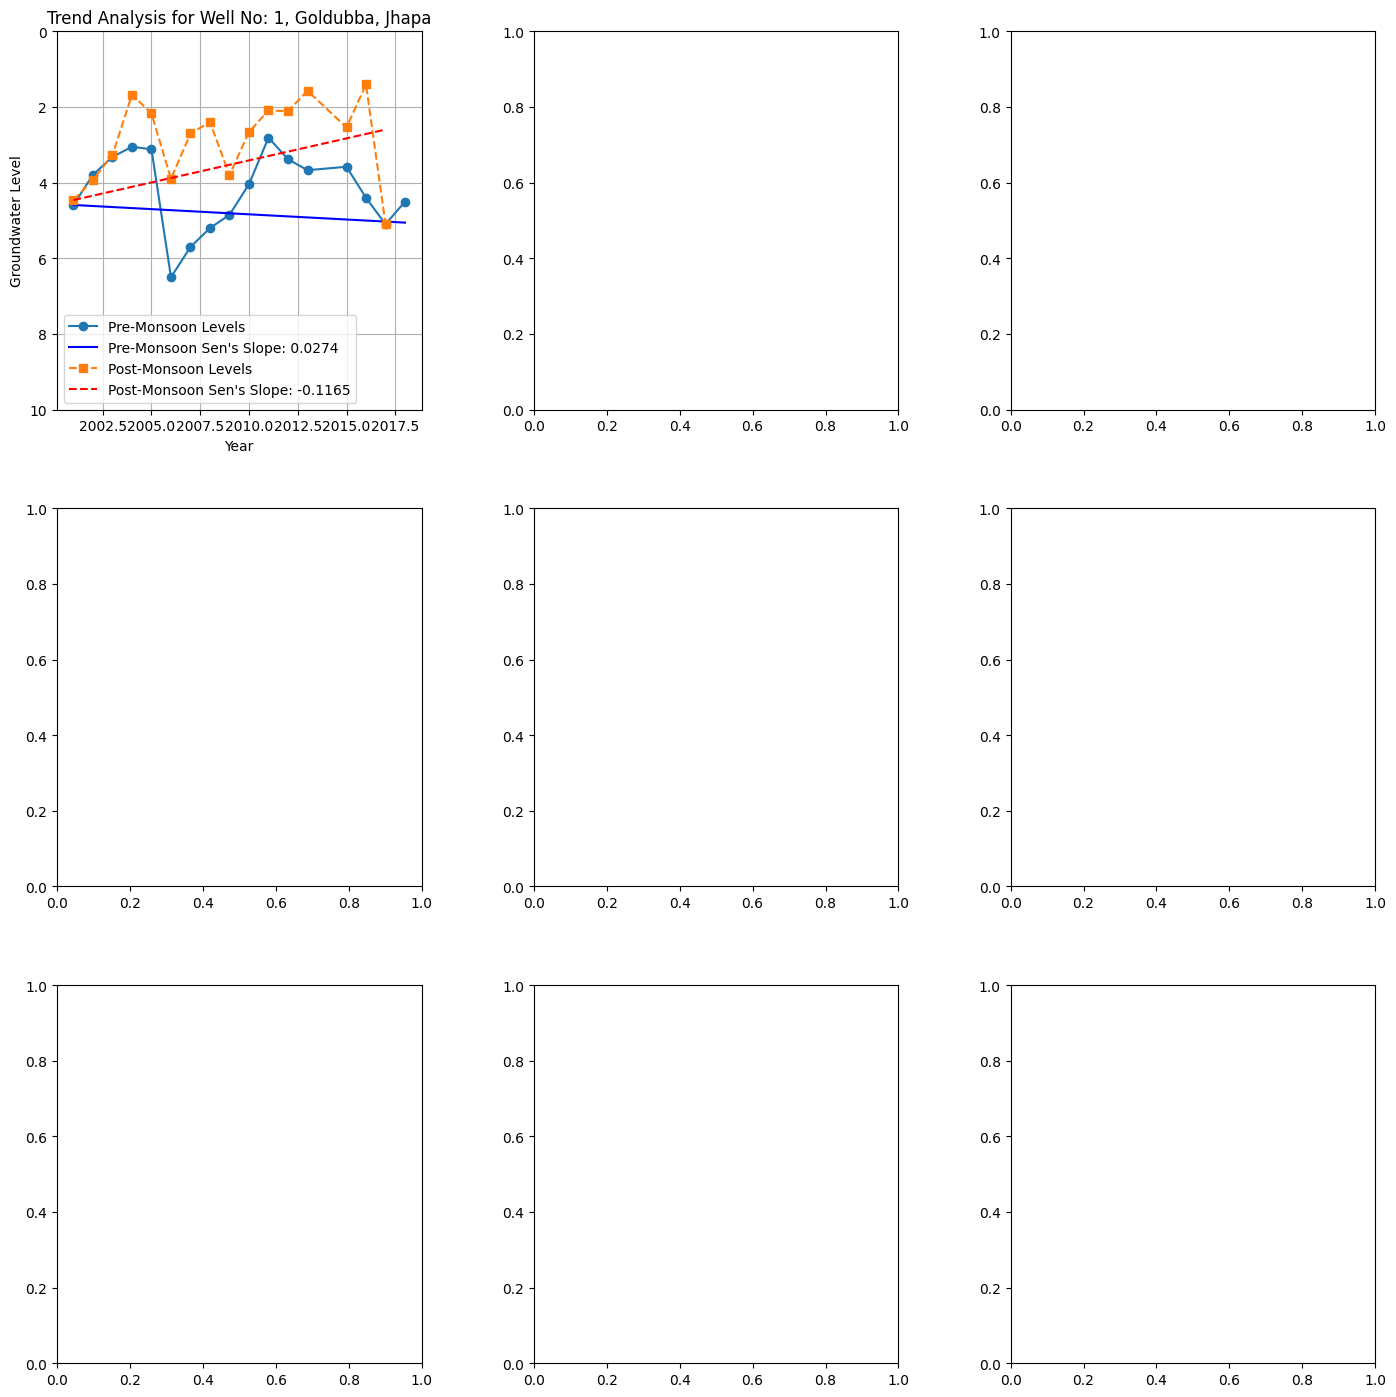

In [3]:
import pandas as pd
import numpy as np
import pymannkendall as mk
import matplotlib.pyplot as plt


def load_and_analyze(file_path, sheet_name, dataset_name):
   
    data = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    
   
    print(f"Data shape for {dataset_name}: {data.shape}")
    
    
    years = data.iloc[0, 4:21].values  
    stations = data.iloc[1:9, 1].values  
    
    
    if data.shape[1] < 23:
        raise ValueError(f"The Excel file for {dataset_name} does not have enough columns. Expected at least 23 columns.")
    
 
    well_numbers = data.iloc[1:9, 21].values  
    district_names = data.iloc[1:9, 22].values  
    
    
    if len(stations) != len(well_numbers) or len(stations) != len(district_names):
        raise ValueError(f"Mismatch in the number of stations, well numbers, or district names in {dataset_name}.")
    
    
    groundwater_levels = data.iloc[1:9, 4:21].values  

    results = []

    for i, station in enumerate(stations):
        levels = groundwater_levels[i]
        levels = pd.to_numeric(levels, errors='coerce')
        valid_indices = ~np.isnan(levels)
        
        # Check if years are valid (not NaN)
        valid_years = pd.to_numeric(years, errors='coerce')
        if np.all(np.isnan(valid_years)):
            print(f"Skipping Station {station} in {dataset_name}: All years are NaN.")
            continue
        
        valid_years = valid_years[valid_indices]
        valid_levels = levels[valid_indices]
        
        if len(valid_levels) < 2:
            print(f"Skipping Station {station} in {dataset_name}: Insufficient data points for analysis.")
            continue
        
        try:
            mk_result = mk.original_test(valid_levels, alpha=0.05)
        except Exception as e:
            print(f"Error performing Mann-Kendall test for Station {station} in {dataset_name}: {e}")
            continue
        
        try:
            sen_slope = mk.sens_slope(valid_levels)
        except Exception as e:
            print(f"Error performing Sen's slope estimation for Station {station} in {dataset_name}: {e}")
            continue
        
        results.append({
            'Station': station,
            'Well Number': well_numbers[i],
            'District Name': district_names[i],
            'Dataset': dataset_name,
            'MK Z Value': mk_result.z,
            'MK Trend': mk_result.trend,
            'MK Tau': mk_result.Tau,
            'Sen\'s Slope': sen_slope.slope,
            'Intercept': sen_slope.intercept,
            'Valid Years': valid_years,
            'Valid Levels': valid_levels,
            'years':years
        })
    
    return results


pre_monsoon_file = './dpre.xlsx' 
post_monsoon_file = './dpost.xlsx'  
sheet_name = 'sheet_1'  

pre_monsoon_results = load_and_analyze(pre_monsoon_file, sheet_name, 'Pre-Monsoon')
post_monsoon_results = load_and_analyze(post_monsoon_file, sheet_name, 'Post-Monsoon')


combined_results = {}

for result in pre_monsoon_results:
    combined_results[result['Station']] = {'Pre-Monsoon': result}

for result in post_monsoon_results:
    if result['Station'] in combined_results:
        combined_results[result['Station']]['Post-Monsoon'] = result
    else:
        combined_results[result['Station']] = {'Post-Monsoon': result}


for station, data in combined_results.items():
    print(f"Station: {station}")
    print(f"Well Number: {data['Pre-Monsoon']['Well Number']}")
    print(f"District Name: {data['Pre-Monsoon']['District Name']}")
    
    if 'Pre-Monsoon' in data:
        pre_data = data['Pre-Monsoon']
        print("\nPre-Monsoon Results:")
        print(f"  MK Trend: {pre_data['MK Trend']}")
        print(f"  MK Z Value: {pre_data['MK Z Value']:.4f}")
        print(f"  MK Tau: {pre_data['MK Tau']:.4f}")
        print(f"  Sen's Slope: {pre_data['Sen\'s Slope']:.4f}")
        print(f"  Intercept: {pre_data['Intercept']:.4f}")
    
    if 'Post-Monsoon' in data:
        post_data = data['Post-Monsoon']
        print("\nPost-Monsoon Results:")
        print(f"  MK Trend: {post_data['MK Trend']}")
        print(f"  MK Z Value: {post_data['MK Z Value']:.4f}")
        print(f"  MK Tau: {post_data['MK Tau']:.4f}")
        print(f"  Sen's Slope: {post_data['Sen\'s Slope']:.4f}")
        print(f"  Intercept: {post_data['Intercept']:.4f}")
    
    print("-" * 60)

# Plotting 
num_stations = len(combined_results)
num_cols = 3  
num_rows = (num_stations + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.tight_layout(pad=5.0)

for idx, (station, data) in enumerate(combined_results.items()):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col]
    
    if 'Pre-Monsoon' in data:
        pre_data = data['Pre-Monsoon']
        ax.plot(pre_data['Valid Years'], pre_data['Valid Levels'], marker='o', label='Pre-Monsoon Levels')
        ax.plot(pre_data['Valid Years'], pre_data['Sen\'s Slope'] * (pre_data['Valid Years'] - pre_data['Valid Years'][0]) + pre_data['Valid Levels'][0], 
                label=f"Pre-Monsoon Sen's Slope: {pre_data['Sen\'s Slope']:.4f}", color='blue')
    
    if 'Post-Monsoon' in data:
        post_data = data['Post-Monsoon']
        if len(post_data['Valid Years']) > 0:  
            ax.plot(post_data['Valid Years'], post_data['Valid Levels'], marker='s', linestyle='--', label='Post-Monsoon Levels')
            ax.plot(post_data['Valid Years'], post_data['Sen\'s Slope'] * (post_data['Valid Years'] - post_data['Valid Years'][0]) + post_data['Valid Levels'][0], 
                    label=f"Post-Monsoon Sen's Slope: {post_data['Sen\'s Slope']:.4f}", color='red', linestyle='--')
        else:
            print(f"Skipping Post-Monsoon plot for Station {station}: No valid years.")
    
    
    well_number = data['Pre-Monsoon']['Well Number']
    district_name = data['Pre-Monsoon']['District Name']
    ax.set_title(f"Trend Analysis for Well No: {well_number}, {station}, {district_name}")
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Groundwater Level')
    ax.legend()
    ax.grid(True)
    
    
    ax.set_ylim(10, 0)  
    ax.set_xlim(min(years), max(years))  


for idx in range(num_stations, num_rows * num_cols):
    row = idx // num_cols
    col = idx % num_cols
    fig.delaxes(axes[row, col])

plt.show()